In [1]:
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_parquet("renewables-dataset.parquet")
dataset["Time"] = pd.to_datetime(dataset["Time"])
print(dataset.head())

                       Time ID  demand_MWh  supply_MWh  solar_MWh   wind_MWh  \
0 2012-01-01 00:00:00+00:00  1     75.6549    9.150821        0.0  18.301642   
1 2012-01-01 00:00:00+00:00  2    557.8868    6.196411        0.0  12.392822   
2 2012-01-01 00:00:00+00:00  3     15.5237    6.855084        0.0  13.710167   
3 2012-01-01 00:00:00+00:00  4      8.6425    7.824092        0.0  15.648183   
4 2012-01-01 00:00:00+00:00  5     85.3649    2.053690        0.0   4.107380   

   solar_rel_prod  wind_rel_prod   latitude  longitude country  \
0             0.0         0.0284  42.094674  -8.113982     POR   
1             0.0         0.0103  41.587435  -8.326462     POR   
2             0.0         0.0283  41.585994  -6.722728     POR   
3             0.0         0.0408  41.597684  -6.342848     POR   
4             0.0         0.0092  41.373957  -7.350949     POR   

   solar_layout_MW  wind_layout_MW  
0         982.8607        644.4240  
1        1361.0601       1203.1866  
2         7

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

dataset = dataset[["Time", "country", "demand_MWh"]]
dataset = dataset.set_index("Time")

countries = dataset["country"].unique()


In [3]:
results_dict = {}

for country in countries:
    print(country)
    country_df = dataset[dataset["country"] == country].copy()
    country_df = country_df.drop(columns=["country"])

    country_df = country_df.groupby(country_df.index).sum()

    mean = np.mean(country_df["demand_MWh"])
    std = np.std(country_df["demand_MWh"])
    country_df["demand_MWh"] = (country_df["demand_MWh"] - mean) / std
    

    country_df["hour"] = country_df.index.hour
    country_df["day_of_week"] = country_df.index.day_of_week
    country_df["month"] = country_df.index.month
    
    
    reg_df = pd.get_dummies(country_df, columns=["day_of_week"], prefix="day_of_week", drop_first=False)
    reg_df = pd.get_dummies(reg_df, columns=["month"], prefix="month", drop_first=False)
    reg_df = pd.get_dummies(reg_df, columns = ["hour"], prefix = "hour", drop_first = False)
 
    

    col_hour_start_idx = 20
    hour_chunks = 6

    for i in range(hour_chunks):
        reg_df[f"hour_chunk_{i}"] = reg_df.iloc[:, col_hour_start_idx + i*4 : col_hour_start_idx + (i+1)*4].sum(axis = 1)
    reg_df = reg_df.drop(columns = [f"hour_{i}" for i in range(24)])

    X = reg_df.drop(columns = ["hour_chunk_1", "month_1", "day_of_week_1"]).iloc[:, 1:].to_numpy().astype(float)
    X = sm.add_constant(X)
    y = reg_df .to_numpy()[:, 0].astype(float)


   
    model = sm.OLS(y, X)
    res = model.fit()
    
  
    results_dict[country] = {
        "params": res.params,
        "pvalues": res.pvalues,
        "rsquared": res.rsquared,
    }

POR
ESP
FRA
BEL
CHE
LUX
NLD
ITA
DEU
AUT
DNK
CZE
POL
HUN
SVK
SVN
HRV
GRC
ALB
MKD
BGR
MNE
BIH
SRB
ROU


In [4]:
params_df = pd.DataFrame({
    country: results_dict[country]["params"]
    for country in countries
}).T  

print(params_df.head())

           0         1         2         3         4         5         6   \
POR -0.303848 -0.144173  0.030627  0.025451 -0.005106 -0.683006 -1.025683   
ESP  0.145691 -0.163308  0.008433 -0.012863 -0.077709 -0.707035 -1.132512   
FRA  1.070743 -0.122001  0.015842  0.001380 -0.046156 -0.495312 -0.716189   
BEL  0.453893 -0.189829  0.034236  0.024792 -0.053671 -0.774320 -1.083566   
CHE  1.110118 -0.096982 -0.014899 -0.038774 -0.100247 -0.636971 -0.835683   

           7         8         9   ...        13        14        15  \
POR  0.062561 -0.466553 -0.800897  ... -0.901275 -0.634060 -0.784870   
ESP  0.206270 -0.357921 -0.746375  ... -0.482026 -0.504804 -0.784689   
FRA  0.316354 -0.622126 -1.181424  ... -2.099889 -1.788107 -1.503625   
BEL  0.146724 -0.345951 -0.753857  ... -1.240171 -0.921266 -0.661347   
CHE  0.272736 -0.426246 -1.259853  ... -1.871806 -1.479883 -1.219798   

           16        17        18        19        20        21        22  
POR -0.449313 -0.182337  0.2

In [20]:
portugal_month = []

row = params_df.loc["POR"]

for i in range(8, 19):
    expected_value = (
        row.iloc[1:7].mean()
        + row.iloc[19:24].mean()
        + row.iloc[0]
        + row.iloc[i]
    )
    portugal_month.append(expected_value)
    
portugal_month

[0.517078662416436,
 0.18273459242548495,
 0.09254293458034346,
 0.1828528869541397,
 0.4549942044671227,
 0.08235634293065386,
 0.3495712265505694,
 0.19876152279819492,
 0.534318725524519,
 0.8012945298139168,
 1.2060716719009636]

In [6]:
params_df.to_csv("params_df.csv", index=True)

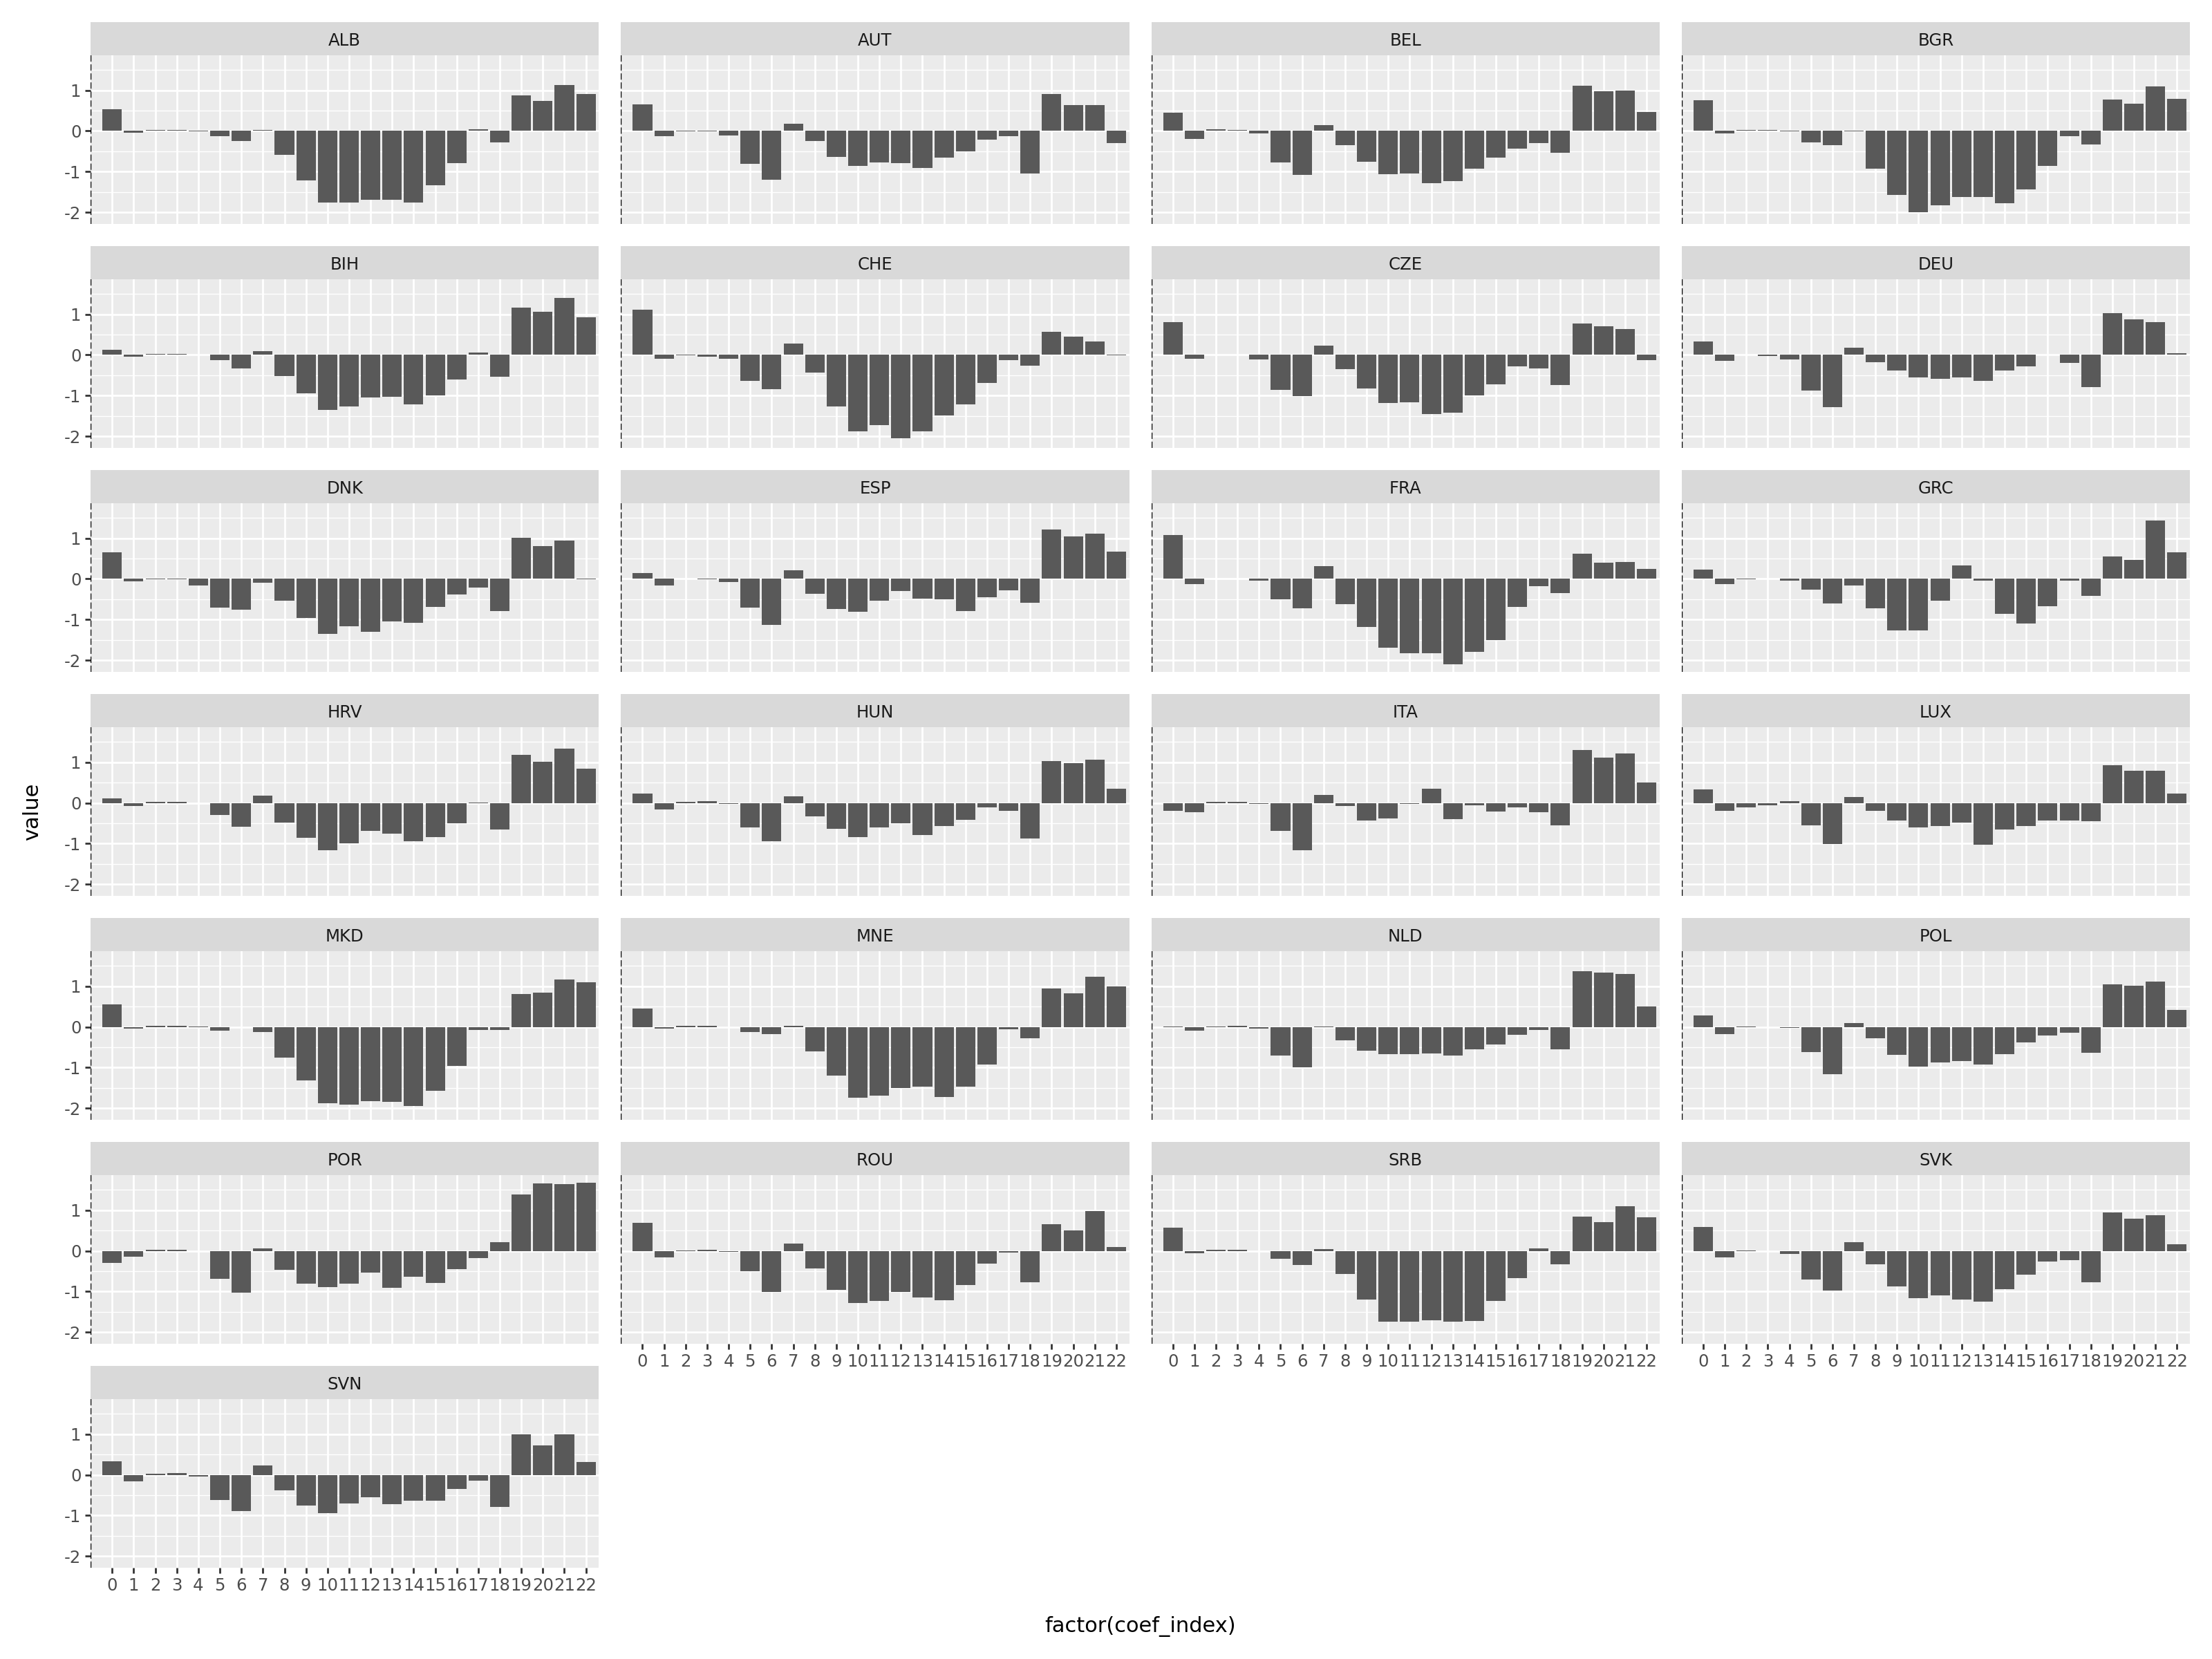

In [5]:

coef_df = params_df.reset_index().melt(
    id_vars="index",
    var_name="coef_index",
    value_name="value"
)


coef_df = coef_df.rename(columns={"index": "country"})


from plotnine import ggplot, aes, geom_col, facet_wrap, geom_vline, theme

(
    ggplot(coef_df, aes(y="value", x="factor(coef_index)"))
    + geom_col()
    + geom_vline(xintercept=0, linetype="dashed")
    + facet_wrap("~country", ncol=4)
    + theme(figure_size=(16, 12))  
)



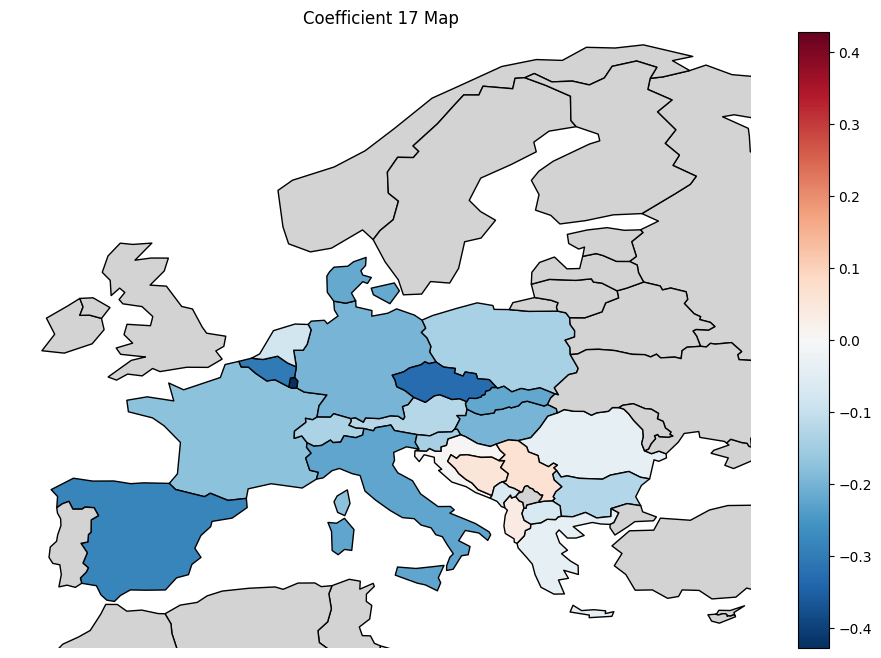

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

colors = [
    "#053061", "#2166ac", "#4393c3", "#92c5de", "#d1e5f0",
    "#f7f7f7",
    "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"
]

cmap = LinearSegmentedColormap.from_list("custom_diverging", colors)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)


coefficient=17
coef_series = params_df[coefficient]

df = coef_series.reset_index()
df.columns = ["iso_a3", "value"]

merged = world.merge(df, left_on="ADM0_A3", right_on="iso_a3", how="left")

fig, ax = plt.subplots(figsize=(12, 8))

vmax = abs(merged["value"]).max()

merged.plot(
    column="value",
    cmap=cmap,
    vmin=-vmax,
    edgecolor= "black",
    vmax=vmax,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_xlim(-12, 35)
ax.set_ylim(33, 72)

ax.set_title(f"Coefficient {coefficient} Map")
ax.axis("off")

plt.show()